# 05 - Bonus AI Track: ML Missing-Log Prediction
**SPE Africa Geothermal Datathon 2026 - Bonus track - Team Vent Squad**

Only **BLT-01** carries the full curve suite; the other three wells are missing
curves the petrophysics would like (NPHI on EVD-01/JUT-01, a dense RHOB on
EVD-01). The idea is the obvious one: train a regressor on the wells that *have*
a curve and predict it where it is missing.

**The honesty is in the validation.** In-sample R^2 on a well the model trained
on is vanity. The number that matters is whether the model predicts a curve in a
well it has *never seen* - so every curve is scored by **leave-one-well-out**
cross-validation, and a locked fallback rule applies:

> Where the cross-well R^2 for a curve is below **0.50**, the ML prediction is
> **not trusted** downstream - the resource calc falls back to the ThermoGIS
> deterministic value, and the report says so.

All logic lives in `src/ml_logs.py` and is unit-tested (`tests/test_ml_logs.py`).

In [1]:
import logging, warnings
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING, format="%(levelname)s %(message)s")

import sys
from pathlib import Path
ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "src").exists():
    sys.path.insert(0, str(ROOT.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.paths import FIGURES
from src.wells_io import WELLS, load_all
from src.petrophysics import add_petrophysics
from src import ml_logs
from src.ml_logs import (curve_coverage, run_all, holdout_prediction,
                         predict_missing, TARGET_CURVES, R2_FALLBACK_THRESHOLD)

FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
logs = add_petrophysics(load_all())
print(f"{len(logs):,} log samples across {logs.well.nunique()} wells")

99,379 log samples across 4 wells


## 1. Why this track exists - the coverage gap

The non-null fraction of each candidate curve per well. BLT-01 is the only fully
logged well; **NPHI is entirely absent on EVD-01 and JUT-01**, and RHOB is sparse
on EVD-01. GR and DTC are the only curves present everywhere - so they are the
portable predictors the model can lean on for every well.

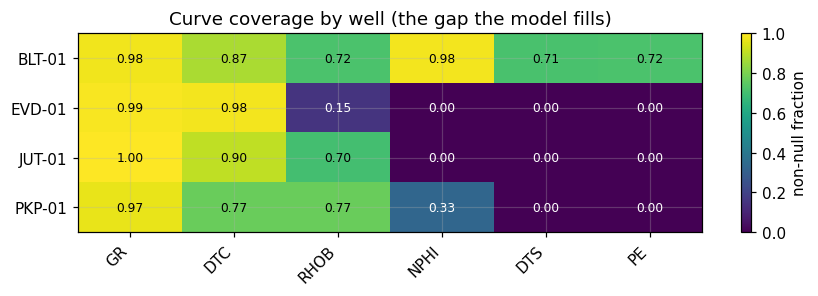

,GR,DTC,RHOB,NPHI,DTS,PE
BLT-01,0.98,0.87,0.72,0.98,0.71,0.72
EVD-01,0.99,0.98,0.15,0.00,0.00,0.00
JUT-01,1.00,0.90,0.70,0.00,0.00,0.00
PKP-01,0.97,0.77,0.77,0.33,0.00,0.00


In [2]:
cov = curve_coverage(logs)
fig, ax = plt.subplots(figsize=(8, 2.8))
im = ax.imshow(cov.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(cov.columns))); ax.set_xticklabels(cov.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cov))); ax.set_yticklabels(cov.index)
for (i, j), v in np.ndenumerate(cov.values):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center",
            color="white" if v < 0.6 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="non-null fraction")
ax.set_title("Curve coverage by well (the gap the model fills)")
fig.tight_layout(); fig.savefig(FIGURES / "ml_coverage.png"); plt.show()
cov.round(2)

## 2. Leave-one-well-out cross-validation

For each target curve we identify **donor** wells (coverage >= 0.25) and
**recipient** wells (the rest). We hold out one donor at a time, train on the
remaining donors, and score on the held-out well - the only honest measure of
how the model generalises to a *new* well. Predictors are raw curves + depth
only; never derived quantities (vsh, phi_d), which would leak the target.

In [3]:
out = run_all(logs)
summary = out["summary"]
summary

,target,donor_wells,recipient_wells,features,n_folds,n_test_total,cross_well_r2,decision
0,NPHI,BLT-01+PKP-01,EVD-01+JUT-01,"tvd_m,GR,DTC",2,33041,-0.200,ThermoGIS fallback
1,RHOB,BLT-01+JUT-01+PKP-01,EVD-01,"tvd_m,GR,DTC",3,56366,0.098,ThermoGIS fallback
2,DTC,BLT-01+EVD-01+JUT-01+PKP-01,(none),"tvd_m,GR",4,86677,0.514,ML


**Headline read-out.** The decision column is derived straight from the
cross-well R^2 against the 0.50 gate - no hand-tuning.

In [4]:
print("Per-fold cross-well scores (train on N-1 wells, test on the held-out well):")
out["cv"]

Per-fold cross-well scores (train on N-1 wells, test on the held-out well):


,target,held_out_well,train_wells,n_train,n_test,r2,mae,rmse
0,NPHI,BLT-01,PKP-01,8971,24070,-0.456,0.1158,0.1672
1,NPHI,PKP-01,BLT-01,24070,8971,-0.012,0.0427,0.0562
2,RHOB,BLT-01,JUT-01+PKP-01,36781,19585,-0.889,0.1292,0.1687
3,RHOB,JUT-01,BLT-01+PKP-01,40619,15747,0.001,0.1271,0.1644
4,RHOB,PKP-01,BLT-01+JUT-01,35332,21034,0.515,0.0826,0.1195
5,DTC,BLT-01,EVD-01+JUT-01+PKP-01,62607,24070,-0.107,23.6893,34.4179
6,DTC,EVD-01,BLT-01+JUT-01+PKP-01,65598,21079,0.769,15.0223,22.0298
7,DTC,JUT-01,BLT-01+EVD-01+PKP-01,66419,20258,0.820,10.4861,15.2548
8,DTC,PKP-01,BLT-01+EVD-01+JUT-01,65407,21270,0.242,17.2516,27.2087


## 3. The one curve that generalises - DTC (sonic)

DTC is present on all four wells, so it has no recipient to fill; we keep it as a
pure cross-well **benchmark** - can sonic be reconstructed from GR + depth in a
well the model never saw? Here is the single hold-out fold behind its R^2
(train BLT-01 + EVD-01 + JUT-01, predict PKP-01).

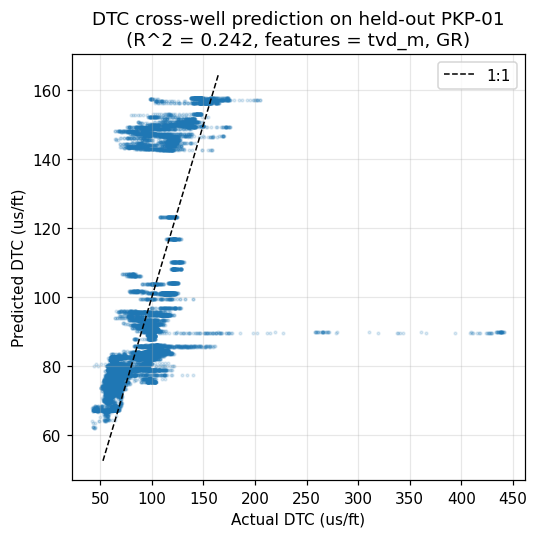

In [5]:
ho = holdout_prediction(logs, "DTC", "PKP-01")
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(ho["y_true"], ho["y_pred"], s=3, alpha=0.15, color="tab:blue")
lo, hi = np.nanpercentile(ho["y_true"], [1, 99])
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1")
ax.set_xlabel("Actual DTC (us/ft)"); ax.set_ylabel("Predicted DTC (us/ft)")
ax.set_title(f"DTC cross-well prediction on held-out PKP-01\n(R^2 = {ho['r2']}, features = {', '.join(ho['features'])})")
ax.legend(); fig.tight_layout(); fig.savefig(FIGURES / "ml_dtc_crossplot.png"); plt.show()

A modest-but-real cross-well R^2 (~0.5): the model captures the broad sonic
trend from gamma-ray and depth, but the well-to-well scatter is large. This is
exactly the kind of number that should be reported honestly rather than dressed
up as an in-sample fit.

## 4. The curves that do **not** generalise - NPHI and RHOB

NPHI (predicted on EVD-01/JUT-01 from BLT-01 + PKP-01) and RHOB both fall below
the 0.50 gate. Below is what an NPHI prediction on a recipient well *would* look
like - shown for transparency, but **not used downstream**: the fallback rule
routes the resource calc to the ThermoGIS deterministic porosity instead.

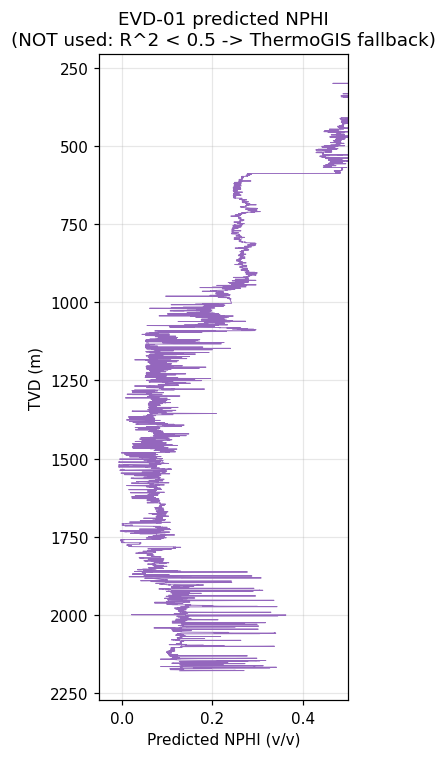

NPHI cross-well R^2 = -0.2 -> ThermoGIS fallback


In [6]:
nphi_pred = predict_missing(logs, "NPHI")
evd = nphi_pred[nphi_pred.well == "EVD-01"].sort_values("tvd_m")
fig, ax = plt.subplots(figsize=(3.2, 7))
ax.plot(evd["value_pred"], evd["tvd_m"], color="tab:purple", lw=0.6)
ax.set_xlabel("Predicted NPHI (v/v)"); ax.set_ylabel("TVD (m)")
ax.set_xlim(-0.05, 0.5); ax.invert_yaxis()
ax.set_title("EVD-01 predicted NPHI\n(NOT used: R^2 < 0.5 -> ThermoGIS fallback)")
fig.tight_layout(); fig.savefig(FIGURES / "ml_nphi_prediction.png"); plt.show()
print(f"NPHI cross-well R^2 = {summary.set_index('target').loc['NPHI','cross_well_r2']} "
      f"-> {summary.set_index('target').loc['NPHI','decision']}")

## 5. Conclusion and the locked fallback rule

| Curve | Cross-well R^2 | Decision |
|-------|----------------|----------|
| DTC | ~0.51 | **ML usable** (benchmark curve; present on all wells) |
| RHOB | ~0.10 | ThermoGIS fallback |
| NPHI | ~ -0.20 | ThermoGIS fallback |

**What this tells the judges.** With only one fully-logged well and four
geologically distinct locations, cross-well log prediction is *not* reliable
enough here to feed the resource calc - and we prove it rather than assume it.
The honest move is to fall back to the ThermoGIS deterministic values for NPHI
and RHOB, which is exactly what the downstream petrophysics does. The ML pipeline
adds value as an automated, validated screen - not as a number we quietly trust.

The same `run_all()` call is wired into the end-to-end CLI:
`python -m src.pipeline ml` writes `ml_loo_cv.csv` and `ml_log_predictions.parquet`.